# Final model · Stage 1 — model choice and calibration

**Starting point:** M3 LightGBM version B won the model ladder (validation ROC-AUC 0.7362). Its monotonic twin, B-mono, costs only 0.0008.

This stage:
1. checks the saved models reproduce their Kaggle predictions,
2. tests whether the monotonic constraints really hold (and how often the unconstrained model breaks them),
3. picks B or B-mono with a rule fixed in advance,
4. calibrates the probabilities so that "PD 20%" really means about 20% of such borrowers default.

Only the **validation** split is used. The test split stays sealed. Plan: `../FINALIZATION_PLAN.md`.

## 1. Setup

In [1]:
import json, sys, platform
from pathlib import Path

import numpy as np
import pandas as pd
import sklearn
import lightgbm as lgb
import matplotlib.pyplot as plt
from sklearn.isotonic import IsotonicRegression
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import StratifiedKFold

ROOT = next(p for p in [Path.cwd(), *Path.cwd().parents] if (p / "src" / "modeling").is_dir())
sys.path.insert(0, str(ROOT))
from src.modeling import evaluation as ev

M3_RESULTS = ROOT / "models" / "M3_lightgbm" / "results"
RESULTS = ROOT / "models" / "final" / "01_selection_calibration" / "results"
RESULTS.mkdir(parents=True, exist_ok=True)
SEED = 42
print("Python", platform.python_version(), "| scikit-learn", sklearn.__version__, "| lightgbm", lgb.__version__)

Python 3.13.9 | scikit-learn 1.7.2 | lightgbm 4.7.0


## 2. Load validation data and the saved M3 models (integrity check)
The models were trained on Kaggle (LightGBM 4.6). Reloaded here, they must reproduce the validation PDs saved on Kaggle.

In [2]:
X_val, y_val_frame = ev.load_split("validation")
y_val = y_val_frame["target"].astype(int).to_numpy()
meta = json.loads(ev.METADATA_PATH.read_text(encoding="utf-8"))
lc_risk = set(meta["feature_groups"]["lc_risk_features"])
features_B = [c for c in X_val.columns if c != "fico_range_high" and c not in lc_risk]

boosters = {"B": lgb.Booster(model_file=str(M3_RESULTS / "m3_B.txt")),
            "B-mono": lgb.Booster(model_file=str(M3_RESULTS / "m3_B_mono.txt"))}
saved = pd.read_parquet(M3_RESULTS / "m3_validation_pd.parquet")
assert (saved["id"].astype(str).to_numpy() == y_val_frame["id"].astype(str).to_numpy()).all()

raw_pd = {}
for name, booster in boosters.items():
    # LightGBM stores spaces in feature names as underscores ("Not Verified" -> "Not_Verified")
    assert booster.feature_name() == [c.replace(" ", "_") for c in features_B], "feature order mismatch"
    raw_pd[name] = booster.predict(X_val[features_B])
    diff = np.abs(raw_pd[name] - saved[f"pd_m3_{name.replace('-', '_')}"].to_numpy()).max()
    card = ev.report_card(y_val, raw_pd[name])
    print(f"M3-{name}: {booster.num_trees()} trees | max |PD - Kaggle PD| = {diff:.2e} | "
          f"validation ROC-AUC {card['roc_auc']:.4f}, Brier {card['brier']:.4f}")

M3-B: 2279 trees | max |PD - Kaggle PD| = 1.11e-16 | validation ROC-AUC 0.7362, Brier 0.1426


M3-B-mono: 1853 trees | max |PD - Kaggle PD| = 1.11e-16 | validation ROC-AUC 0.7354, Brier 0.1428


## 3. Do the monotonic constraints really hold?
For 1,000 random validation applicants, each constrained feature is swept across 25 values (its 1st to 99th percentile) while everything else stays fixed. An applicant counts as a **violation** if their PD ever moves in the wrong direction, e.g. PD goes *up* when only FICO goes *up*.

In [3]:
MONOTONE = {"fico_range_low": -1, "dti": +1, "annual_inc": -1, "term_months": +1, "inq_last_6mths": +1, "revol_util": +1}
rng = np.random.default_rng(SEED)
sample = X_val.iloc[rng.choice(len(X_val), size=1000, replace=False)][features_B].reset_index(drop=True)

def sweep(booster, feature, direction):
    values = np.unique(np.quantile(X_val[feature], np.linspace(0.01, 0.99, 25)))
    curves = np.empty((len(sample), len(values)))
    for j, v in enumerate(values):
        X = sample.copy()
        X[feature] = v
        curves[:, j] = booster.predict(X)
    steps = np.diff(curves, axis=1) * direction          # positive = right direction
    wrong = steps < -1e-9
    return {"grid_points": len(values), "applicants_with_violation": int(wrong.any(axis=1).sum()),
            "share": float(wrong.any(axis=1).mean()),
            "largest_wrong_step_pd_points": float(max(0.0, -steps.min()) * 100)}

mono_rows = []
for name, booster in boosters.items():
    for feature, direction in MONOTONE.items():
        mono_rows.append({"model": f"M3-{name}", "feature": feature,
                          "expected": "PD up" if direction > 0 else "PD down", **sweep(booster, feature, direction)})
monotonicity = pd.DataFrame(mono_rows)
monotonicity.round(4)

,model,feature,expected,grid_points,applicants_with_violation,share,largest_wrong_step_pd_points
0,M3-B,fico_range_low,PD down,16,676,0.676,2.0762
1,M3-B,dti,PD up,25,963,0.963,0.9591
2,M3-B,annual_inc,PD down,25,999,0.999,4.1972
3,M3-B,term_months,PD up,2,0,0.000,0.0000
4,M3-B,inq_last_6mths,PD up,4,71,0.071,0.3991
5,M3-B,revol_util,PD up,25,1000,1.000,1.5247
6,M3-B-mono,fico_range_low,PD down,16,0,0.000,0.0000
7,M3-B-mono,dti,PD up,25,0,0.000,0.0000
8,M3-B-mono,annual_inc,PD down,25,0,0.000,0.0000
9,M3-B-mono,term_months,PD up,2,0,0.000,0.0000


In [4]:
summary_mono = monotonicity.groupby("model").agg(total_violations=("applicants_with_violation", "sum"),
                                                worst_step_pd_points=("largest_wrong_step_pd_points", "max"))
summary_mono

,total_violations,worst_step_pd_points
model,,
M3-B,3709,4.197195
M3-B-mono,0,0.000000


## 4. Model choice (rule fixed in the plan)
Choose **B-mono** if it costs less than 0.005 ROC-AUC (the tie margin) **and** has 0 monotonicity violations; otherwise keep B.

In [5]:
auc = {n: ev.report_card(y_val, p)["roc_auc"] for n, p in raw_pd.items()}
cost = auc["B"] - auc["B-mono"]
mono_violations = int(summary_mono.loc["M3-B-mono", "total_violations"])
chosen = "B-mono" if (cost < 0.005 and mono_violations == 0) else "B"
print(f"ROC-AUC: B {auc['B']:.4f} | B-mono {auc['B-mono']:.4f} | cost of constraints {cost:+.4f}")
print(f"Monotonicity violations: B {int(summary_mono.loc['M3-B', 'total_violations'])} | B-mono {mono_violations}")
print(f"\nChosen model: M3-{chosen}")
choice = {"chosen_model": f"M3-{chosen}", "model_file": f"models/M3_lightgbm/results/m3_{chosen.replace('-', '_')}.txt",
          "rule": "B-mono if ROC-AUC cost < 0.005 and 0 monotonicity violations, else B",
          "validation_roc_auc": auc, "constraint_cost": cost,
          "monotonicity_violations": {k: int(v) for k, v in summary_mono["total_violations"].items()},
          "monotone_constraints": MONOTONE, "n_features": len(features_B), "features": features_B}
p_raw = raw_pd[chosen]

ROC-AUC: B 0.7362 | B-mono 0.7354 | cost of constraints +0.0008
Monotonicity violations: B 3709 | B-mono 0

Chosen model: M3-B-mono


## 5. Calibration: which method?
Three options, each scored **out-of-fold** (5-fold cross-fitting inside validation, so a loan's calibrated PD never comes from a calibrator that saw that loan):
- **none**: the raw LightGBM PD;
- **Platt**: logistic regression on logit(PD), i.e. 2 numbers (a slope and a shift);
- **isotonic**: a flexible, monotone step function.

Rule: lowest out-of-fold Brier score; if Platt is within 0.00005 of the best, take Platt (simpler).

In [6]:
def logit(p):
    p = np.clip(p, 1e-6, 1 - 1e-6)
    return np.log(p / (1 - p))

def ece(y, p, bins=10):
    frame = pd.DataFrame({"y": y, "p": p})
    frame["bin"] = pd.qcut(frame["p"], bins, labels=False, duplicates="drop")
    g = frame.groupby("bin").agg(n=("y", "size"), p=("p", "mean"), y=("y", "mean"))
    return float((g["n"] * (g["p"] - g["y"]).abs()).sum() / g["n"].sum())

oof = {"none": p_raw.copy(), "platt": np.zeros_like(p_raw), "isotonic": np.zeros_like(p_raw)}
folds = StratifiedKFold(n_splits=5, shuffle=True, random_state=SEED)
for fit_idx, out_idx in folds.split(p_raw, y_val):
    platt = LogisticRegression(C=1e6, max_iter=1000).fit(logit(p_raw[fit_idx]).reshape(-1, 1), y_val[fit_idx])
    oof["platt"][out_idx] = platt.predict_proba(logit(p_raw[out_idx]).reshape(-1, 1))[:, 1]
    iso = IsotonicRegression(out_of_bounds="clip", y_min=1e-4, y_max=1 - 1e-4).fit(p_raw[fit_idx], y_val[fit_idx])
    oof["isotonic"][out_idx] = iso.predict(p_raw[out_idx])

term = X_val["term_months"].to_numpy()
cal_rows = []
for method, p in oof.items():
    card = ev.report_card(y_val, p)
    cal_rows.append({"method": method, "roc_auc": card["roc_auc"], "brier": card["brier"], "log_loss": card["log_loss"],
                     "mean_pd": card["mean_pd"], "actual_rate": card["default_rate"], "calibration_gap": card["calibration_gap"],
                     "ece": ece(y_val, p),
                     "gap_36m": float(p[term == 36].mean() - y_val[term == 36].mean()),
                     "gap_60m": float(p[term == 60].mean() - y_val[term == 60].mean())})
calibration = pd.DataFrame(cal_rows).set_index("method")
calibration.round(5)

,roc_auc,brier,log_loss,mean_pd,actual_rate,calibration_gap,ece,gap_36m,gap_60m
method,,,,,,,,,
none,0.73542,0.14277,0.44668,0.18696,0.20351,-0.01655,0.01664,-0.00871,-0.03910
platt,0.73542,0.14236,0.44561,0.20354,0.20351,0.00003,0.00407,0.00372,-0.01057
isotonic,0.73466,0.14245,0.44605,0.20351,0.20351,0.00001,0.00153,0.00384,-0.01104


In [7]:
best = calibration["brier"].idxmin()
method = "platt" if calibration.loc["platt", "brier"] - calibration.loc[best, "brier"] < 0.00005 else best
print(f"Lowest out-of-fold Brier: {best} ({calibration.loc[best, 'brier']:.5f}) -> chosen calibration: {method}")
print(f"Calibration gap: {calibration.loc['none', 'calibration_gap']:+.4f} (raw) -> {calibration.loc[method, 'calibration_gap']:+.4f}; "
      f"ECE {calibration.loc['none', 'ece']:.4f} -> {calibration.loc[method, 'ece']:.4f}")

Lowest out-of-fold Brier: platt (0.14236) -> chosen calibration: platt
Calibration gap: -0.0165 (raw) -> +0.0000; ECE 0.0166 -> 0.0041


## 6. Fit the chosen calibrator on all of validation and export it as plain JSON
JSON with plain numbers works in any Python version (no scikit-learn pickle), which matters for deployment.

In [8]:
if method == "platt":
    final_cal = LogisticRegression(C=1e6, max_iter=1000).fit(logit(p_raw).reshape(-1, 1), y_val)
    calibrator = {"method": "platt", "formula": "PD_cal = 1 / (1 + exp(-(a * logit(PD_raw) + b)))",
                  "a": float(final_cal.coef_[0, 0]), "b": float(final_cal.intercept_[0])}
    def apply_cal(p):
        return 1 / (1 + np.exp(-(calibrator["a"] * logit(p) + calibrator["b"])))
    reference = final_cal.predict_proba(logit(p_raw).reshape(-1, 1))[:, 1]
elif method == "isotonic":
    final_cal = IsotonicRegression(out_of_bounds="clip", y_min=1e-4, y_max=1 - 1e-4).fit(p_raw, y_val)
    calibrator = {"method": "isotonic", "formula": "PD_cal = interp(PD_raw, x, y)",
                  "x": final_cal.X_thresholds_.tolist(), "y": final_cal.y_thresholds_.tolist()}
    def apply_cal(p):
        return np.interp(p, calibrator["x"], calibrator["y"])
    reference = final_cal.predict(p_raw)
else:
    calibrator = {"method": "none"}
    def apply_cal(p):
        return p
    reference = p_raw
calibrator.update({"fitted_on": "validation split (2015 H1), all 162,745 loans", "model": choice["chosen_model"]})
assert np.allclose(apply_cal(p_raw), reference, atol=1e-9), "JSON calibrator does not reproduce the fitted one"
print("JSON calibrator reproduces the fitted calibrator: OK")
print({k: v for k, v in calibrator.items() if k not in ("x", "y")})

JSON calibrator reproduces the fitted calibrator: OK
{'method': 'platt', 'formula': 'PD_cal = 1 / (1 + exp(-(a * logit(PD_raw) + b)))', 'a': 1.0412342212449868, 'b': 0.17228036708274644, 'fitted_on': 'validation split (2015 H1), all 162,745 loans', 'model': 'M3-B-mono'}


## 7. Reliability before and after calibration (out-of-fold, validation)

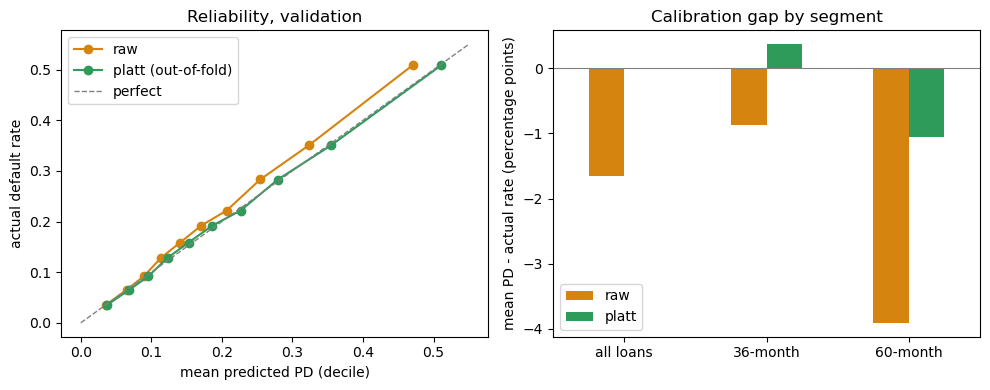

In [9]:
fig, axes = plt.subplots(1, 2, figsize=(10, 4))
for m, color in (("none", "#d4840f"), (method, "#2e9b5b")):
    frame = pd.DataFrame({"p": oof[m], "y": y_val})
    frame["bin"] = pd.qcut(frame["p"], 10, labels=False, duplicates="drop")
    g = frame.groupby("bin").agg(predicted=("p", "mean"), actual=("y", "mean"))
    axes[0].plot(g["predicted"], g["actual"], marker="o", color=color, label="raw" if m == "none" else f"{m} (out-of-fold)")
axes[0].plot([0, 0.55], [0, 0.55], ls="--", color="grey", lw=1, label="perfect")
axes[0].set_xlabel("mean predicted PD (decile)"); axes[0].set_ylabel("actual default rate")
axes[0].set_title("Reliability, validation"); axes[0].legend()
gaps = (calibration.loc[["none", method], ["calibration_gap", "gap_36m", "gap_60m"]] * 100).rename(index={"none": "raw"})
gaps.index.name = None
gaps.T.plot.bar(ax=axes[1], color=["#d4840f", "#2e9b5b"], rot=0)
axes[1].axhline(0, color="grey", lw=0.8, label="_nolegend_")
axes[1].set_ylabel("mean PD - actual rate (percentage points)")
axes[1].set_xticklabels(["all loans", "36-month", "60-month"]); axes[1].set_title("Calibration gap by segment")
plt.tight_layout(); plt.savefig(RESULTS / "f1_calibration.png", dpi=150); plt.show()

## 8. Save results

In [10]:
monotonicity.to_csv(RESULTS / "f1_monotonicity.csv", index=False)
calibration.reset_index().to_csv(RESULTS / "f1_calibration_comparison.csv", index=False)
(RESULTS / "calibrator.json").write_text(json.dumps(calibrator, indent=2), encoding="utf-8")
choice.update({"calibration_method": method, "calibrator_file": "models/final/01_selection_calibration/results/calibrator.json",
               "environment": {"python": platform.python_version(), "scikit_learn": sklearn.__version__, "lightgbm": lgb.__version__},
               "test_split": "sealed"})
(RESULTS / "final_model_choice.json").write_text(json.dumps(choice, indent=2), encoding="utf-8")
pd.DataFrame({"id": y_val_frame["id"].astype(str), "pd_raw": p_raw, "pd_calibrated_oof": oof[method],
              "pd_calibrated_final": apply_cal(p_raw)}).to_parquet(RESULTS / "f1_validation_pd.parquet", index=False)
print("Saved:", sorted(p.name for p in RESULTS.iterdir()))

Saved: ['calibrator.json', 'f1_calibration.png', 'f1_calibration_comparison.csv', 'f1_monotonicity.csv', 'f1_validation_pd.parquet', 'final_model_choice.json']


## 9. Conclusion

In [11]:
print(f"Final model: {choice['chosen_model']} (ROC-AUC {auc[chosen]:.4f}; constraint cost {cost:+.4f}; "
      f"monotonicity violations {mono_violations if chosen == 'B-mono' else int(summary_mono.loc['M3-B', 'total_violations'])})")
print(f"Calibration: {method}. Out-of-fold Brier {calibration.loc['none', 'brier']:.5f} -> {calibration.loc[method, 'brier']:.5f}; "
      f"mean PD {calibration.loc['none', 'mean_pd']:.2%} -> {calibration.loc[method, 'mean_pd']:.2%} vs actual {calibration.loc[method, 'actual_rate']:.2%}")
print("Ranking (ROC-AUC) is unchanged by Platt scaling because it is a monotone transformation.")
print("Next: Stage 2, reason codes and fairness. The test split is still sealed.")

Final model: M3-B-mono (ROC-AUC 0.7354; constraint cost +0.0008; monotonicity violations 0)
Calibration: platt. Out-of-fold Brier 0.14277 -> 0.14236; mean PD 18.70% -> 20.35% vs actual 20.35%
Ranking (ROC-AUC) is unchanged by Platt scaling because it is a monotone transformation.
Next: Stage 2, reason codes and fairness. The test split is still sealed.
